<a href="https://colab.research.google.com/github/tilangelo/ML.2025-26/blob/main/Dz_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание №6
## Трек D – Кластеризация + классификация новостей

Цель работы:
- провести кластеризацию новостей
- обучить модель для предсказания кластера
- сравнить несколько подходов векторизации
- продемонстрировать практическое применение

In [48]:
!pip install pymorphy3 gensim scikit-learn nltk

In [49]:
import pandas as pd
import numpy as np
import sqlite3

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from gensim.models import Word2Vec

import matplotlib.pyplot as plt


## 1. Загрузка данных
Используем базу новостей, собранную в предыдущей работе.


In [50]:
conn = sqlite3.connect("articles.db")

df = pd.read_sql_query("SELECT * FROM articles", conn)

conn.close()

df.head()

,guid,url,title,description,published_at,comments_count,rating,created_at_utc
0,5081222,https://www.hab.kp.ru/online/news/5081222/,Украли краденое: в Хабаровске избили и ограбил...,В Хабаровске завершили расследование уголовног...,2023-01-01T02:08:03,None,None,2025-12-15T11:42:38.381161500
1,5081227,https://www.hab.kp.ru/online/news/5081227/,В Магадане инспекторы начали ловить нетрезвых ...,Утро 1 января началось для госавтоинспекторов ...,2023-01-01T02:54:21,None,None,2025-12-15T11:42:36.355664600
2,5081231,https://www.hab.kp.ru/online/news/5081231/,«Забег обещаний» стартует в Хабаровске 1 января,В Хабаровске в первый день нового 2023 года тр...,2023-01-01T03:59:58,None,None,2025-12-15T11:42:34.241586100
3,5081241,https://www.hab.kp.ru/online/news/5081241/,Поживился на съемной квартире: житель Хабаровс...,В Хабаровске центральный районный суд вынес пр...,2023-01-01T05:02:51,None,None,2025-12-15T11:42:31.133534200
4,5081251,https://www.hab.kp.ru/online/news/5081251/,Прокуратура Хабаровского района контролирует х...,В Хабаровском крае прокуратура контролирует хо...,2023-01-01T05:50:07,None,None,2025-12-15T11:42:29.033054200


In [51]:
df.shape

(5291, 8)

In [52]:
df.guid.nunique(), len(df)

(5291, 5291)

In [53]:
df["text"] = ( df["title"].fillna("") + " " + df["description"] )
df["text"] = df["text"].str.lower()
df["text"].iloc[0][:500]

'украли краденое: в хабаровске избили и ограбили курьера, работавшего на мошенников в хабаровске завершили расследование уголовного дела по статье за кражу и передали материалы в суд на рассмотрение по существу. как сообщает су ск россии по хабаровскому краю и еао, пятеро человек избили и забрали деньги у курьера, который работал на мошенников. курьер был несовершеннолетним.\n\n- завершено расследование уголовного дела в отношении 15-ти, 17-ти, 20-ти, 21- и 24-летних жителей города хабаровска и хаб'

## 2. Предобработка текста


Очистка:

In [54]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^а-яa-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

Токенизация:

In [55]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download('punkt_tab') # Added to ensure Russian punkt_tab is available

stop_words = set(stopwords.words("russian"))

def tokenize(text):
    tokens = word_tokenize(text, language='russian')
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df["tokens"] = df["clean_text"].apply(tokenize)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 3. Обучение Word2Vec

модель токенизации word2vec

In [56]:
w2v_model = Word2Vec(
    sentences=df["tokens"],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

Функция для токенизации документа(всей строки)

In [57]:
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


1. Для каждой строки новый столбец с вектором документа.

In [58]:
df["w2v_vector"] = df["tokens"].apply(lambda x: document_vector(x, w2v_model))

X_w2v = np.vstack(df["w2v_vector"])

## 4. Векторизация TF-IDF (baseline)

In [59]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["clean_text"])

## 5. Кластеризация текстов (KMeans)

In [60]:
k = 10

kmeans = KMeans(n_clusters=k, random_state=144)
df["cluster"] = kmeans.fit_predict(X_w2v)

print(df["cluster"].value_counts())

cluster
4    1122
1     817
0     680
6     580
9     543
7     466
8     384
2     276
5     261
3     162
Name: count, dtype: int64


In [61]:
df.head()

,guid,url,title,description,published_at,comments_count,rating,created_at_utc,text,clean_text,tokens,w2v_vector,cluster
0,5081222,https://www.hab.kp.ru/online/news/5081222/,Украли краденое: в Хабаровске избили и ограбил...,В Хабаровске завершили расследование уголовног...,2023-01-01T02:08:03,None,None,2025-12-15T11:42:38.381161500,украли краденое: в хабаровске избили и ограбил...,украли краденое в хабаровске избили и ограбили...,"[украли, краденое, хабаровске, избили, ограбил...","[-0.15587491, 0.27450442, 0.07967502, 0.310606...",0
1,5081227,https://www.hab.kp.ru/online/news/5081227/,В Магадане инспекторы начали ловить нетрезвых ...,Утро 1 января началось для госавтоинспекторов ...,2023-01-01T02:54:21,None,None,2025-12-15T11:42:36.355664600,в магадане инспекторы начали ловить нетрезвых ...,в магадане инспекторы начали ловить нетрезвых ...,"[магадане, инспекторы, начали, ловить, нетрезв...","[-0.24227501, 0.31382576, 0.00037278785, 0.205...",9
2,5081231,https://www.hab.kp.ru/online/news/5081231/,«Забег обещаний» стартует в Хабаровске 1 января,В Хабаровске в первый день нового 2023 года тр...,2023-01-01T03:59:58,None,None,2025-12-15T11:42:34.241586100,«забег обещаний» стартует в хабаровске 1 январ...,забег обещаний стартует в хабаровске января в ...,"[забег, обещаний, стартует, хабаровске, января...","[0.27926704, 0.31073567, 0.02430011, -0.335029...",1
3,5081241,https://www.hab.kp.ru/online/news/5081241/,Поживился на съемной квартире: житель Хабаровс...,В Хабаровске центральный районный суд вынес пр...,2023-01-01T05:02:51,None,None,2025-12-15T11:42:31.133534200,поживился на съемной квартире: житель хабаровс...,поживился на съемной квартире житель хабаровск...,"[поживился, съемной, квартире, житель, хабаров...","[-0.18640852, 0.33117178, 0.095053695, 0.30516...",0
4,5081251,https://www.hab.kp.ru/online/news/5081251/,Прокуратура Хабаровского района контролирует х...,В Хабаровском крае прокуратура контролирует хо...,2023-01-01T05:50:07,None,None,2025-12-15T11:42:29.033054200,прокуратура хабаровского района контролирует х...,прокуратура хабаровского района контролирует х...,"[прокуратура, хабаровского, района, контролиру...","[-0.030668717, 0.30962455, 0.040241167, 0.3645...",5


## 6. Оценка качества кластеризации

метрика для кластеризации.

In [62]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_w2v, df["cluster"])
print("Silhouette score:", score)

Silhouette score: 0.19569641


### Подбор оптимального числа кластеров

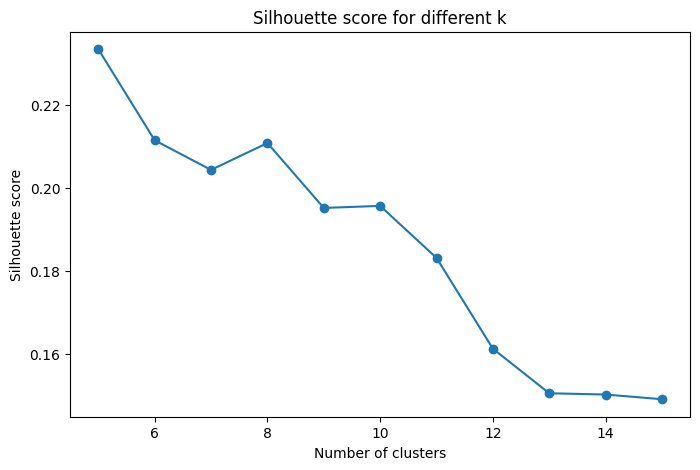

In [63]:
scores = []

for k in range(5, 16):
    kmeans_tmp = KMeans(n_clusters=k, random_state=144)
    labels = kmeans_tmp.fit_predict(X_w2v)
    sc = silhouette_score(X_w2v, labels)
    scores.append(sc)

plt.figure(figsize=(8, 5))
plt.plot(range(5, 16), scores, marker="o")
plt.title("Silhouette score for different k")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

Значение 10, выбранное наугад, не является оптимальным, оптимальное значение где-то в районе 5-6 кластеров.

In [64]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=144)
df["cluster"] = kmeans.fit_predict(X_w2v)

print(df["cluster"].value_counts())

cluster
4    2060
1    1347
0    1047
2     675
3     162
Name: count, dtype: int64


In [65]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_w2v, df["cluster"])
print("Silhouette score:", score)

Silhouette score: 0.23337546


Несмотря на малый рейтинг, снижать количество кластеров не буду, в дальнейшем для разнообразия предсказания оставлю 5

## 7. Интерпретация кластеров

Ключевые слова каждого кластера

In [66]:
from collections import Counter

def show_top_words(cluster_id, n=15):
    words = []
    for tokens in df[df["cluster"] == cluster_id]["tokens"]:
        words.extend(tokens)
    return Counter(words).most_common(n)

for i in range(5):
    print(f"\nCluster {i}:")
    print(show_top_words(i))


Cluster 0:
[('рублей', 1334), ('хабаровск', 1060), ('тысяч', 882), ('мужчина', 804), ('суд', 797), ('дело', 766), ('рассказали', 738), ('года', 642), ('материалов', 594), ('использовании', 592), ('сайта', 587), ('ссылка', 586), ('обязательна', 586), ('уголовное', 529), ('деньги', 501)]

Cluster 1:
[('края', 1941), ('хабаровского', 1559), ('хабаровск', 1384), ('крае', 1273), ('году', 1211), ('хабаровском', 1178), ('материалов', 1070), ('использовании', 1059), ('ссылка', 1056), ('обязательна', 1056), ('сайта', 1055), ('рублей', 844), ('года', 774), ('это', 636), ('также', 627)]

Cluster 2:
[('хабаровск', 724), ('мчс', 440), ('использовании', 397), ('материалов', 397), ('сайта', 395), ('ссылка', 395), ('обязательна', 395), ('рассказали', 394), ('водитель', 389), ('хабаровске', 361), ('дтп', 341), ('россии', 313), ('улице', 301), ('подробнее', 299), ('пожар', 263)]

Cluster 3:
[('градусов', 774), ('днем', 672), ('ночью', 629), ('метров', 616), ('секунду', 584), ('ветер', 440), ('температу

Примеры:

In [67]:
for i in range(5):
    print(f"\n=== Cluster {i} examples ===")
    print(df[df["cluster"] == i]["title"].head(5).tolist())



=== Cluster 0 examples ===
['Украли краденое: в Хабаровске избили и ограбили курьера, работавшего на мошенников', 'В Магадане инспекторы начали ловить нетрезвых водителей', 'Поживился на съемной квартире: житель Хабаровска украл почти всю мебель из арендованного жилья', 'Неизвестный оформил микрозайм на жительницу Магадана', 'Ударил ножом родственника: подозреваемого задержали на Колыме']

=== Cluster 1 examples ===
['«Забег обещаний» стартует в Хабаровске 1 января', 'В «Забеге обещаний» приняли участие 250 жителей и гостей Хабаровска', 'Пятеро детей родились в Хабаровском крае в новогоднюю ночь', '16 ледовых переправ открыто в Хабаровском крае', 'Более 12 тысяч детей появилось на свет в Хабаровском крае']

=== Cluster 2 examples ===
['Прокуратура Хабаровского района контролирует ход проверки по факту гибели трех человек в пожаре', 'Второй пожар за несколько часов: в Хабаровске загорелась квартира в многоэтажном доме', 'В Комсомольске прошли соревнования по стрельбе из боевого пистоле

Наименования кластеров и создание столбца для них

In [68]:
cluster_names = {
  0: " Уголовные дела и суды",
  1: "Общая хроника края, области и тп",
  2: "Прогноз погоды и пр",
  3: "Общие городские новости",
  4: "Происшествия и ЧС (ДТП, пожары)"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

##8.Простая модель

Подготовка данных

Для начала сделаем кластеры на основе TF-IDF

In [69]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=144)
df["cluster"] = kmeans.fit_predict(X_tfidf)

print(df["cluster"].value_counts())

cluster
3    1801
2    1639
0    1075
4     612
1     164
Name: count, dtype: int64


In [70]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Векторизация

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


Обучение Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    multi_class="auto"
)

lr.fit(X_train_tfidf, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto', n_jobs=-1)

Оценка качества

In [73]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9628463476070529
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       323
           1       1.00      0.98      0.99        49
           2       0.96      0.96      0.96       492
           3       0.94      0.98      0.96       540
           4       0.99      0.91      0.95       184

    accuracy                           0.96      1588
   macro avg       0.98      0.96      0.97      1588
weighted avg       0.96      0.96      0.96      1588



##Сложная модель

In [79]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=144)
df["cluster"] = kmeans.fit_predict(X_w2v)

print(df["cluster"].value_counts())

cluster
4    2060
1    1347
0    1047
2     675
3     162
Name: count, dtype: int64


Word2Vec + Ансамблевая модель (RandomForest)

In [80]:
X_w2v = np.vstack(df["w2v_vector"].values)
y = df["cluster"].values

X_w2v.shape

(5291, 100)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X_w2v,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [82]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)


обучение случайного леса

In [83]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

Оценка качества

In [84]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9691435768261965
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       314
           1       0.97      0.97      0.97       404
           2       0.97      0.96      0.97       203
           3       1.00      1.00      1.00        49
           4       0.97      0.96      0.97       618

    accuracy                           0.97      1588
   macro avg       0.97      0.98      0.98      1588
weighted avg       0.97      0.97      0.97      1588

